# **Guided Modul 11 DKA**

In [1]:
print("'Aarif Rahmaan Jalaluddin Faqiih")  # Tuliskan nama lengkap Anda
print("103112430182")  # Tuliskan NIM Anda
print("IF-12-06")  # Tuliskan kelas Anda
print("https://colab.research.google.com/drive/1t625KthWO3qfLr2Q08NmE3nKPIeoEyzg?usp=sharing") # Link collab Praktikum
print("https://colab.research.google.com/drive/1nqxzx0uk2L59t55tZjWv6m07fkvA_HQy?usp=sharing") # Link collab Jurnal
print("https://github.com/aariffaqiih/CAK2HAB3-DASAR-KECERDASAN-ARTIFISIAL/tree/main/MODUL%2011")

'Aarif Rahmaan Jalaluddin Faqiih
103112430182
IF-12-06
https://colab.research.google.com/drive/1t625KthWO3qfLr2Q08NmE3nKPIeoEyzg?usp=sharing
https://colab.research.google.com/drive/1nqxzx0uk2L59t55tZjWv6m07fkvA_HQy?usp=sharing
https://github.com/aariffaqiih/CAK2HAB3-DASAR-KECERDASAN-ARTIFISIAL/tree/main/MODUL%2011


# Pendahuluan

A* adalah algoritma pencarian jalur yang digunakan untuk menemukan jalur terpendek dari node awal (start) ke node tujuan (goal) dalam graf. A* menggabungkan dari UCS dan Greedy BFS dengan mempertimbangkan biaya sebenarnya (g(n)) dan jalur yang telah dilalui, maupun perkiraan biaya (h(n)) dari node saat ini ke node tujuan berdasarkan fungsi heursitik. A* menggunakan fungsi f(n) = g(n) + h(n) untuk memprioritaskan node yang akan dieksplorasi, di mana g(n) adalah biaya dari node awal ke node saat ini, dan h(n) adalah estimasi biaya dari node saat ini ke tujuan. Dengan pendekatan ini, A* memastikan bahwa jalur yang ditemukan adalah jalur optimal. Pada NetworkX, A* dapat diimplementasikan menggunakan fungsi `nx.astar_path()`, yang secara otomatis menghitung jalur terpendek dengan mempertimbangkan biaya sebenarnya dan fungsi heuristik.

# Kode Implementasi A*

In [2]:
import networkx as nx # untuk membuat grafik
import matplotlib.pyplot as plt # untuk plot grafik

In [3]:
# Fungsi pendukung untuk mencetak graf
def show_graph (G, pos=None, title="", labels={}):
    # Membuat pos jika pos tidak diberikan
    if pos is None:
        pos = nx.spring_layout (G)

    # Fungsi untuk menggambar node
    nx.draw(
        G,
        pos, # Posisi node
        with_labels=True, # Menampilkan nama node
        labels=labels, # Menampilkan label setiap node
        node_color='red', # Warna node
        node_size=2000, # Ukuran node
        font_color="white", # Warna font label node
        font_weight="bold", # Ketebalan font label node
        width=5 # Ketebalan garis edge
    )

    # Mengambil label edge jika ada weight
    edge_labels = nx.get_edge_attributes (G, 'weight')

    # Fungsi untuk menggambar label edge
    nx.draw_networkx_edge_labels (
        G,
        pos,
        edge_labels=edge_labels, # Data weight
        font_color='blue', # Warna font label edge
        font_weight="bold", # Berat font label edge
        font_size=12 # Ukuran font label edge
    )

    # Memberikan margin pada plot
    plt.margins (0.2)
    plt.title(title) # Menampilkan judul graf jika diberikan
    plt.show() # Menampilkan graf menggunakan matplotlib

In [4]:
# Posisi node pos agar sesuai dengan gambar contoh
pos = {
    'A': (0, 1),
    'B': (1, 2),
    'C': (1, 0),
    'D': (2, 3),
    'E': (2, 1.5),
    'F': (2, 0)
}

In [5]:
# Inisialisasi graf berarah kosong
G = nx.DiGraph()

In [6]:
# Definisi node dan edge sesuai dengan gambar
edges = [
    ('A', 'B', 2),
    ('A', 'C', 5),
    ('B', 'D', 2),
    ('B', 'E', 4),
    ('C', 'E', 1),
    ('C', 'F', 5),
    ('E', 'D', 3),
    ('E', 'F', 2)
]
# Menambahkan edge pada graf
G.add_weighted_edges_from(edges)

In [7]:
print("Elemen pada Graf:")
print("Daftar Node pada Graf:", G.nodes())
print("Daftar Edge pada Graf:", G.edges())
print("Jumlah Node pada Graf", G.number_of_nodes())
print("Jumlah Edge pada Graf", G.number_of_edges())

Elemen pada Graf:
Daftar Node pada Graf: ['A', 'B', 'C', 'D', 'E', 'F']
Daftar Edge pada Graf: [('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'E'), ('C', 'F'), ('E', 'D'), ('E', 'F')]
Jumlah Node pada Graf 6
Jumlah Edge pada Graf 8


In [8]:
# Mencatat start dan goal node
labels = {node: node for node in G.nodes()}
labels['A'] = 'A\nStart'
labels['F'] = 'F\nGoal'

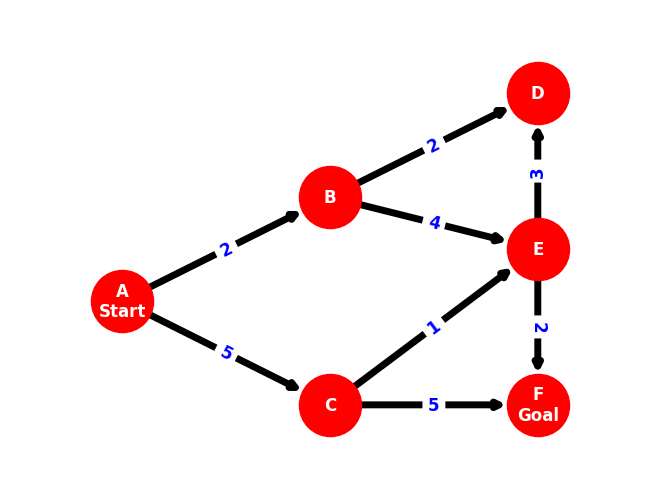

In [9]:
# Mencetak graf
show_graph(G, pos=pos, labels=labels)

In [10]:
def heuristable(a, b):
    if a == 'A':
        return 10
    elif a == 'B':
        return 2
    elif a == 'C':
        return 3
    elif a == 'D':
        return 1
    elif a == 'E':
        return 4
    elif a == 'F':
        return 0

In [11]:
# Mencari node yang dikunjungi dengan weight terkecil dari A ke F
path_node = nx.astar_path(G, 'A', 'F', heuristic=heuristable, weight='weight')

# Mencari weight terkecil dari A ke F
path_length = nx.astar_path_length(G, 'A', 'F', heuristic=heuristable, weight='weight')

# Cetak hasil
print("Node yang dikunjungi dari A ke F:", path_node)
print("Besar weight hasil A* dari A ke F:", path_length)

Node yang dikunjungi dari A ke F: ['A', 'B', 'E', 'F']
Besar weight hasil A* dari A ke F: 8


# Penjelasan Implementasi A*

Kode ini dimulai dengan mengimpor library yang dibutuhkan, yaitu network untuk membuat grafik dan matplotlib.pyplot untuk menampilkan plot grafik.

Setelah itu, dibuat sebuah fungsi bernama show_graph yang berfungsi untuk mencetak graf pada layar. Di dalam fungsi tersebut, jika posisi node tidak diberikan, maka posisi akan dihitung secara otomatis menggunakan spring_layout.

Kemudian, fungsi nx.draw digunakan untuk menggambar node dengan warna merah, ukuran 2000, dan label berwarna putih dengan ketebalan tebal. Selain itu, fungsi nx.draw_networkx_edge_labels juga digunakan untuk menampilkan label pada setiap edge, terutama informasi tentang weight dengan font berwarna biru.

Terakhir, diberikan margin sebesar 0.2, judul graf ditampilkan jika diberikan, dan graf ditampilkan menggunakan plt.show.

Selanjutnya, posisi setiap node didefinisikan secara manual dalam bentuk dictionary agar sesuai dengan tata letak yang diinginkan, di mana node A berada di koordinat (0, 1), B di (1, 2), C di (1, 0), D di (2, 3), E di (2, 1.5), dan F di (2, 0).

Setelah itu, dibuat graf berarah kosong menggunakan nx.DiGraph. Definisi node dan edge kemudian ditambahkan ke dalam graf melalui list edges yang berisi pasangan node beserta weight-nya, yaitu edge dari A ke B dengan weight 2, A ke C dengan weight 5, B ke D dengan weight 2, B ke E dengan weight 4, C ke E dengan weight 1, C ke F dengan weight 5, E ke D dengan weight 3, dan E ke F dengan weight 2.

Seluruh edge tersebut ditambahkan ke graf menggunakan fungsi add_weighted_edges_from.

Setelah graf terbentuk, dilakukan evaluasi terhadap elemen-elemen yang ada di dalam graf, di antaranya daftar node, daftar edge, jumlah node, dan jumlah edge. Hasilnya menunjukkan bahwa graf memiliki 6 node (A, B, C, D, E, F) dan 8 edge. Kemudian, label untuk node start dan goal ditambahkan, di mana node A diberi label "A\nStart" dan node F diberi label "F\nGoal". Label-label tersebut kemudian digunakan saat visualisasi graf melalui fungsi show_graph.

Setelah graf divisualisasikan, dibuat fungsi heuristik bernama heuristable yang menerima parameter node dan mengembalikan nilai heuristik untuk masing-masing node. Nilai heuristik ini digunakan sebagai estimasi jarak dari setiap node ke node tujuan, di mana node A memiliki nilai 10, B memiliki nilai 2, C memiliki nilai 3, D memiliki nilai 1, E memiliki nilai 4, dan F memiliki nilai 0 karena F merupakan node tujuan.

Kemudian, dilakukan pencarian jalur dari node A ke node F menggunakan algoritma A* (A-Star) dengan memanfaatkan fungsi nx.astar_path dan nx.astar_path_length. Fungsi astar_path digunakan untuk mencari urutan node yang dikunjungi dengan weight terkecil, sedangkan astar_path_length digunakan untuk menghitung besar weight total dari jalur tersebut.

Hasilnya menunjukkan bahwa node yang dikunjungi dari A ke F adalah A, B, E, F dengan total weight sebesar 8, yang berarti jalur terpendek dari A ke F melewati node B dan E terlebih dahulu sebelum sampai ke node F.

# Kode Graf Peta Eropa

=== IMPLEMENTASI A* (ARAD -> BUCHAREST) ===
Jalur terpendek yang ditemukan: Arad -> Sibiu -> Rimnicu Vilcea -> Pitesti -> Bucharest
Total bobot (jarak): 418 km


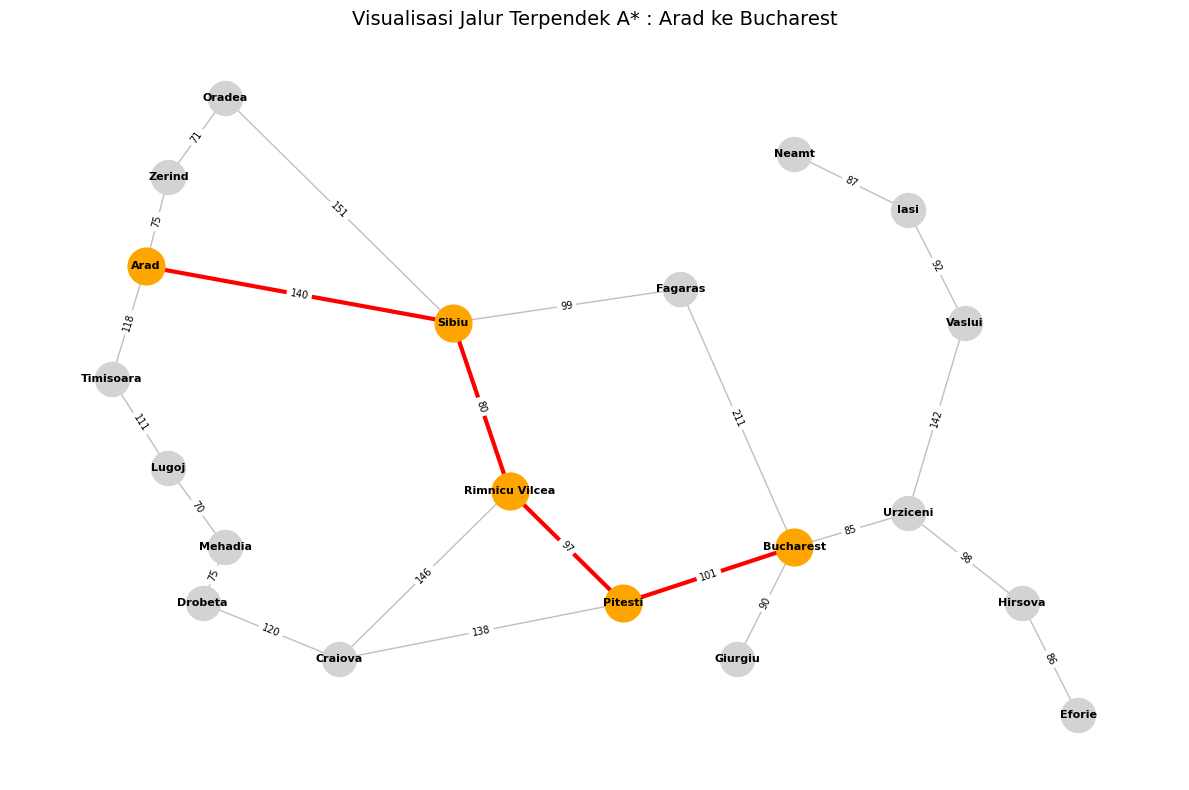

In [12]:
import networkx as nx
import matplotlib.pyplot as plt
import math

# 1. Inisialisasi Graf (Gunakan nx.Graph untuk graf tidak berarah)
G = nx.Graph()

# 2. Definisi Koordinat (X, Y) untuk Heuristik & Visualisasi
# Koordinat ini digunakan untuk menghitung Euclidean Distance
pos = {
    "Oradea": (1.5, 9.5), "Zerind": (1.0, 8.8), "Arad": (0.8, 8.0),
    "Timisoara": (0.5, 7.0), "Lugoj": (1.0, 6.2), "Mehadia": (1.5, 5.5),
    "Drobeta": (1.3, 5.0), "Craiova": (2.5, 4.5), "Sibiu": (3.5, 7.5),
    "Rimnicu Vilcea": (4.0, 6.0), "Pitesti": (5.0, 5.0), "Fagaras": (5.5, 7.8),
    "Bucharest": (6.5, 5.5), "Giurgiu": (6.0, 4.5), "Urziceni": (7.5, 5.8),
    "Vaslui": (8.0, 7.5), "Iasi": (7.5, 8.5), "Neamt": (6.5, 9.0),
    "Hirsova": (8.5, 5.0), "Eforie": (9.0, 4.0)
}

# 3. Tambahkan Edge dengan Bobot (Jarak sebenarnya di peta)
edges = [
    ("Oradea", "Zerind", 71), ("Zerind", "Arad", 75), ("Arad", "Timisoara", 118),
    ("Timisoara", "Lugoj", 111), ("Lugoj", "Mehadia", 70), ("Mehadia", "Drobeta", 75),
    ("Drobeta", "Craiova", 120), ("Craiova", "Pitesti", 138), ("Craiova", "Rimnicu Vilcea", 146),
    ("Pitesti", "Bucharest", 101), ("Bucharest", "Giurgiu", 90), ("Bucharest", "Urziceni", 85),
    ("Urziceni", "Hirsova", 98), ("Hirsova", "Eforie", 86), ("Urziceni", "Vaslui", 142),
    ("Vaslui", "Iasi", 92), ("Iasi", "Neamt", 87), ("Sibiu", "Oradea", 151),
    ("Sibiu", "Arad", 140), ("Sibiu", "Rimnicu Vilcea", 80), ("Sibiu", "Fagaras", 99),
    ("Fagaras", "Bucharest", 211), ("Rimnicu Vilcea", "Pitesti", 97)
]
G.add_weighted_edges_from(edges)

# 4. Fungsi Heuristik: Euclidean Distance
def heuristic_euclidean(u, v):
    x1, y1 = pos[u]
    x2, y2 = pos[v]
    # Rumus: sqrt((x2-x1)^2 + (y2-y1)^2)
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

# 5. Eksekusi Algoritma A* (Arad ke Bucharest)
start_node = "Arad"
goal_node = "Bucharest"

path = nx.astar_path(G, source=start_node, target=goal_node,
                     heuristic=heuristic_euclidean, weight='weight')
path_length = nx.astar_path_length(G, source=start_node, target=goal_node,
                                   heuristic=heuristic_euclidean, weight='weight')

# 6. Cetak Hasil
print(f"=== IMPLEMENTASI A* (ARAD -> BUCHAREST) ===")
print(f"Jalur terpendek yang ditemukan: {' -> '.join(path)}")
print(f"Total bobot (jarak): {path_length} km")

# 7. Visualisasi Graf
plt.figure(figsize=(12, 8))

# Gambar semua node dan edge dasar
nx.draw_networkx_nodes(G, pos, node_size=600, node_color='lightgrey')
nx.draw_networkx_edges(G, pos, width=1, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold')

# Highlight jalur hasil A* dengan warna merah
path_edges = list(zip(path, path[1:]))
nx.draw_networkx_nodes(G, pos, nodelist=path, node_color='orange', node_size=700)
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=3)

# Label bobot edge
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)

plt.title(f"Visualisasi Jalur Terpendek A* : {start_node} ke {goal_node}", fontsize=14)
plt.axis('off')
plt.tight_layout()
plt.show()

# Penjelasan Graf Peta Eropa

Kode ini dimulai dengan mengimpor tiga library, yaitu networkx yang berfungsi untuk membuat dan mengelola struktur graf, matplotlib.pyplot yang berfungsi untuk membuat visualisasi graf, dan math yang berfungsi untuk perhitungan matematika seperti operasi akar kuadrat.

Kemudian, dibuat objek graf tidak berarah menggunakan nx.Graph() dan disimpan di variabel G.

Dari sini, didefinisikan koordinat X dan Y untuk setiap kota dalam dictionary bernama pos yang berisi 20 kota dari peta Romania.

Koordinat ini berfungsi dua hal, yaitu untuk menghitung jarak Euclidean antar kota sebagai nilai heuristik, dan juga untuk menentukan posisi node saat graf divisualisasikan nantinya.

Setelah koordinat didefinisikan, dibuat list bernama edges yang berisi pasangan kota beserta bobotnya yang merupakan jarak sebenarnya di peta Romania. Ada total 23 edge yang menghubungkan kota-kota tersebut.

List ini kemudian dimasukkan ke dalam graf menggunakan G.add_weighted_edges_from(edges), sehingga graf sekarang memiliki edge dengan informasi jarak antar kota.

Setelah itu, didefinisikan fungsi bernama heuristic_euclidean(u, v) yang berfungsi untuk menghitung jarak Euclidean antara dua node berdasarkan koordinatnya.

Caranya adalah mengambil koordinat x dan y dari kedua node, lalu menghitung akar dari jumlah kuadrat selisih koordinatnya menggunakan rumus sqrt((x2-x1)^2 + (y2-y1)^2).

Fungsi ini yang nantinya digunakan sebagai panduan untuk algoritma A* dalam memperkirakan jarak tersisa dari node saat ini ke tujuan.

Kemudian, dilakukan eksekusi algoritma A* dengan menentukan node awal yaitu Arad dan node tujuan yaitu Bucharest. Algoritma ini dijalankan menggunakan nx.astar_path() yang mencari jalur terpendek dari Arad ke Bucharest dengan memanfaatkan fungsi heuristik Euclidean dan bobot edge yang sudah didefinisikan.

Selain jalurnya, juga dihitung total panjang jalur menggunakan nx.astar_path_length(), sehingga hasilnya berupa urutan kota yang dilalui dan total jarak tempuh dalam satuan kilometer.

Terakhir, dibuat visualisasi graf menggunakan matplotlib. Pertama, semua node dan edge digambar dengan warna default berupa abu-abu dengan ukuran node 600 dan ketebalan edge 1.

Kemudian, node yang termasuk dalam jalur hasil A* di-highlight dengan warna orange dengan ukuran lebih besar yaitu 700, dan edge jalur di-highlight dengan warna merah dengan ketebalan 3, sehingga jalur terpendek terlihat jelas dibandingkan graf secara keseluruhan.

Label bobot juga ditambahkan pada setiap edge agar informasi jarak antar kota bisa terlihat, lalu visualisasi ini ditampilkan menggunakan plt.show().